In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
%matplotlib inline
sns.set_style("whitegrid")

In [47]:
df= pd.read_csv(r'C:\Users\emaan\Downloads\netflix_data.csv')

In [48]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   duration      7787 non-null   int64 
 9   description   7787 non-null   object
 10  genre         7787 non-null   object
dtypes: int64(2), object(9)
memory usage: 669.3+ KB


In [50]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
duration           0
description        0
genre              0
dtype: int64

In [51]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [52]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'duration',
 'description',
 'genre']

In [53]:
df = df.dropna(subset=['duration'])

In [54]:
df['date_added'] = pd.to_datetime(df['date_added'],format='%Y-%m-%d',errors='coerce')

In [55]:
df['added_year'] = df['date_added'].dt.year


In [56]:
movies = df[df['type'] == 'Movie'].copy()

In [57]:
movies['duration_min'] = movies['duration'].apply(lambda x: float(''.join(filter(str.isdigit, str(x)))))

In [58]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre,added_year,duration_min
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,NaT,2016,93,After a devastating earthquake hits Mexico Cit...,Dramas,NaN,93.0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,NaT,2011,78,"When an army recruit is found dead, his fellow...",Horror Movies,NaN,78.0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,NaT,2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action,NaN,80.0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,NaT,2008,123,A brilliant group of students become card-coun...,Dramas,NaN,123.0
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,NaT,2019,95,"After an awful accident, a couple admitted to ...",Horror Movies,NaN,95.0


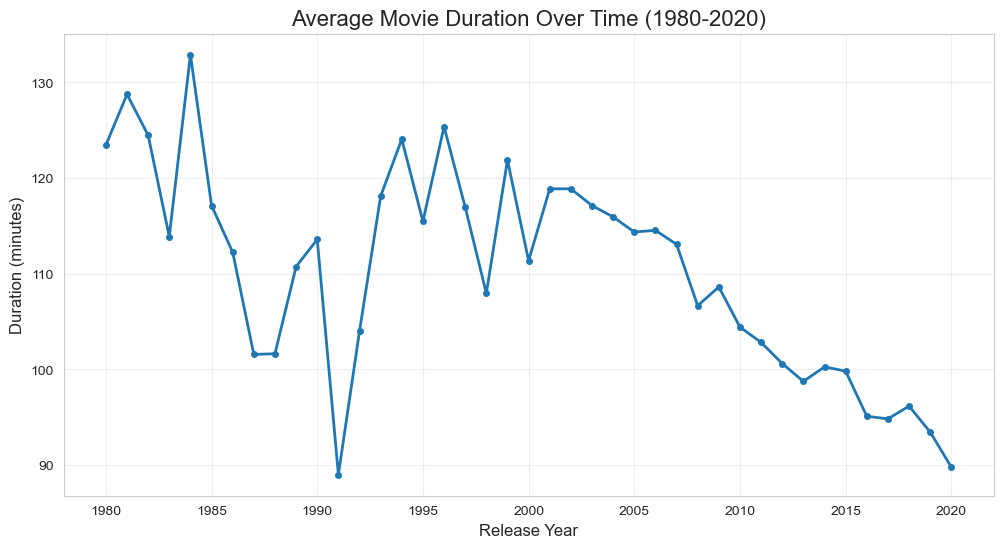

Average duration in 1980: 123 minutes
Average duration in 2020: 90 minutes


In [59]:
duration_by_year = movies.groupby('release_year')['duration_min'].mean().reset_index()

# Filter for years 1980-2020
duration_by_year = duration_by_year[(duration_by_year['release_year'] >= 1980) & 
                                     (duration_by_year['release_year'] <= 2020)]
plt.figure(figsize=(12, 6))
plt.plot(duration_by_year['release_year'], duration_by_year['duration_min'], 
         marker='o', linewidth=2, markersize=4)
plt.title('Average Movie Duration Over Time (1980-2020)', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# FIXED: Correct way to access values
avg_1980 = duration_by_year[duration_by_year['release_year'] == 1980]['duration_min'].values
avg_2020 = duration_by_year[duration_by_year['release_year'] == 2020]['duration_min'].values

if len(avg_1980) > 0 and len(avg_2020) > 0:
    print(f"Average duration in 1980: {avg_1980[0]:.0f} minutes")
    print(f"Average duration in 2020: {avg_2020[0]:.0f} minutes")
else:
    print("Data not available for 1980 or 2020")

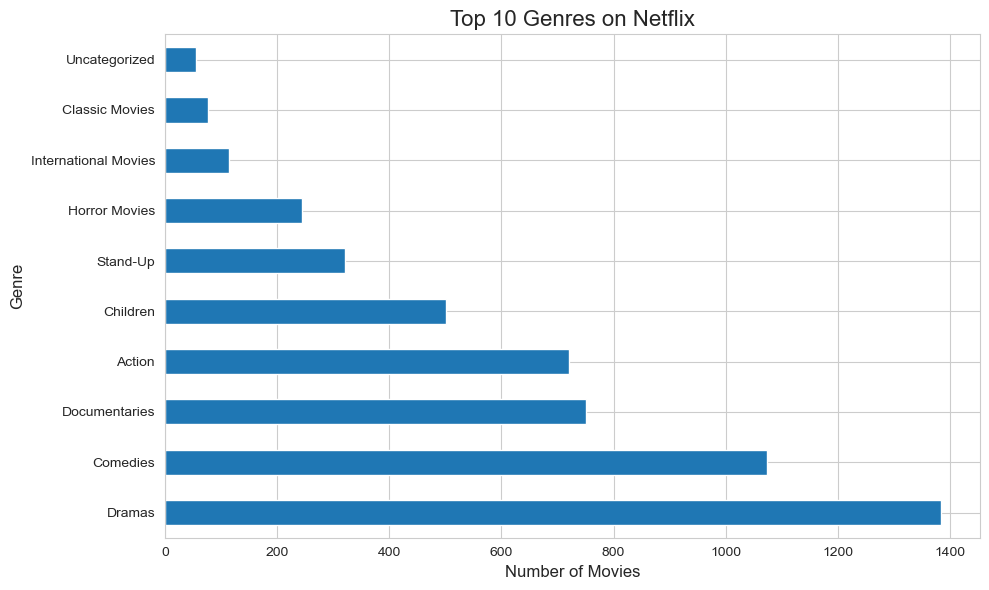

Top 3 genres:
  Dramas: 1384 movies
  Comedies: 1074 movies
  Documentaries: 751 movies


In [60]:
all_genres = movies['genre'].str.split(', ').explode()

# Count movies per genre
genre_counts = all_genres.value_counts().head(10)

plt.figure(figsize=(10, 6))
genre_counts.plot(kind='barh')
plt.title('Top 10 Genres on Netflix', fontsize=16)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 3 genres:")
for genre, count in genre_counts.head(3).items():
    print(f"  {genre}: {count} movies")

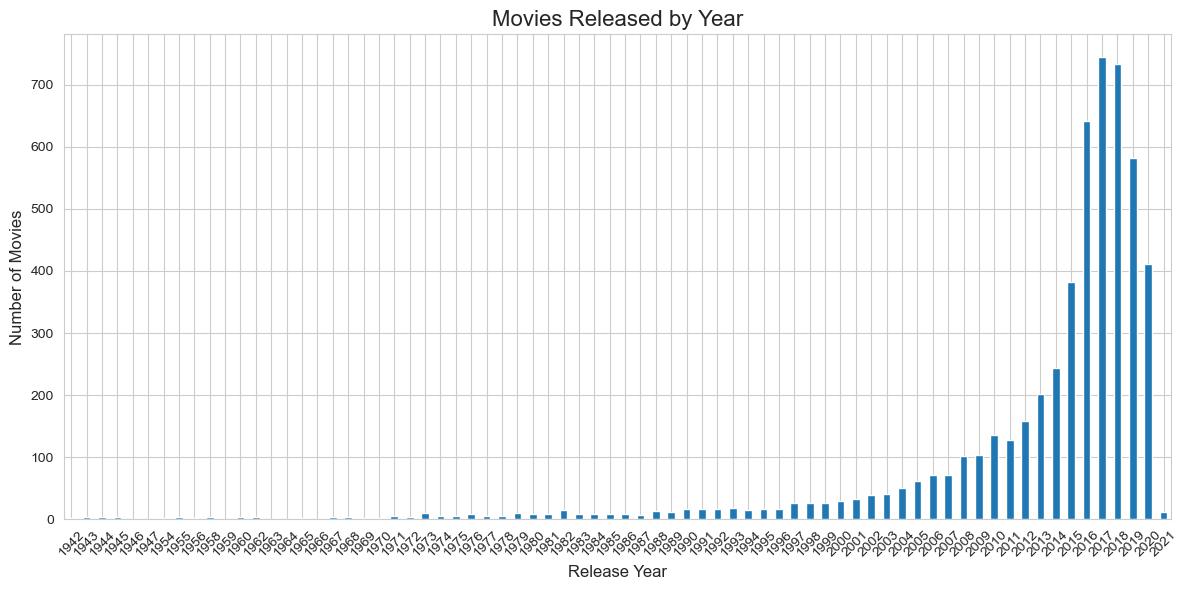

Peak year: 2017 with 744 movies released


In [61]:
release_by_year = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
release_by_year.plot(kind='bar')  # Changed from added_by_year to release_by_year
plt.title('Movies Released by Year', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# FIXED: Proper print statement
peak_year = release_by_year.idxmax()
peak_count = release_by_year.max()
print(f"Peak year: {peak_year} with {peak_count} movies released")

In [62]:
longest_movies = movies.nlargest(10, 'duration_min')[['title', 'duration_min', 'release_year', 'genre']]
longest_movies

,title,duration_min,release_year,genre
957,Black Mirror: Bandersnatch,312.0,2018,Dramas
6850,The School of Mischief,253.0,1973,Comedies
4490,No Longer kids,237.0,1979,Comedies
3694,Lock Your Girls In,233.0,1982,Comedies
5108,Raya and Sakina,230.0,1984,Comedies
5376,Sangam,228.0,1964,Classic Movies
3521,Lagaan,224.0,2001,Dramas
3195,Jodhaa Akbar,214.0,2008,Action
3282,Kabhi Khushi Kabhie Gham,209.0,2001,Dramas
6507,The Irishman,209.0,2019,Dramas


In [63]:
movies.to_csv('cleaned_netflix_movies.csv', index=False)
print("Cleaned data saved as 'cleaned_netflix_movies.csv'")

# Summary statistics
print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"Total movies analyzed: {len(movies)}")
print(f"Average movie duration: {movies['duration_min'].mean():.1f} minutes")
print(f"Median movie duration: {movies['duration_min'].median():.1f} minutes")
print(f"Longest movie: {movies.loc[movies['duration_min'].idxmax(), 'title']} ({movies['duration_min'].max():.0f} min)")
print(f"Shortest movie: {movies.loc[movies['duration_min'].idxmin(), 'title']} ({movies['duration_min'].min():.0f} min)")
print(f"Most common genre: {genre_counts.index[0]} ({genre_counts.values[0]} movies)")


Cleaned data saved as 'cleaned_netflix_movies.csv'

PROJECT SUMMARY
Total movies analyzed: 5377
Average movie duration: 99.3 minutes
Median movie duration: 98.0 minutes
Longest movie: Black Mirror: Bandersnatch (312 min)
Shortest movie: Silent (3 min)
Most common genre: Dramas (1384 movies)
